In [114]:
import pandas as pd

In [115]:
df = pd.read_csv('used_cars.csv')

In [116]:
df.shape

(4340, 8)

In [117]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [118]:
df['seller_type'].unique()

<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

In [119]:
df['transmission'].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [120]:
df['owner'].unique()

<StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str

In [121]:
df['name'].nunique()

1491

In [122]:
df['fuel'].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [124]:
df = pd.get_dummies(df, columns=['transmission'], drop_first=True)

In [125]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,owner,transmission_Manual
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,First Owner,True
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,First Owner,True
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,First Owner,True
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,First Owner,True
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Second Owner,True


In [126]:
df['fuel_ids'] = df['fuel'].replace(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], [0, 1, 2, 3, 4])

In [127]:
df['fuel_ids'] = df['fuel_ids'].astype(int)

In [128]:
df['seller_ids'] = df['seller_type'].replace(['Individual', 'Dealer', 'Trustmark Dealer'], [0, 1, 2])

In [129]:
df['seller_ids'] = df['seller_ids'].astype(int)

In [130]:
df['owner_ids'] = df['owner'].replace(['First Owner','Second Owner','Third Owner','Fourth & Above Owner','Test Drive Car'], [0, 1, 2, 3, 4])

In [131]:
df['owner_ids'] = df['owner_ids'].astype(int)

In [132]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,owner,transmission_Manual,fuel_ids,seller_ids,owner_ids
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,First Owner,True,0,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,First Owner,True,0,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,First Owner,True,1,0,0
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,First Owner,True,0,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Second Owner,True,1,0,1


In [133]:
features = ['year','km_driven','transmission_Manual','seller_ids','owner_ids']

In [134]:
target = 'selling_price'

In [135]:
X = df[features]

In [136]:
y = df[target]

In [153]:
corr_data = df[['year','km_driven','transmission_Manual','seller_ids','owner_ids','selling_price']]

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

In [138]:
column_names = ['year','km_driven','fuel_ids','seller_ids','owner_ids', 'selling_price']

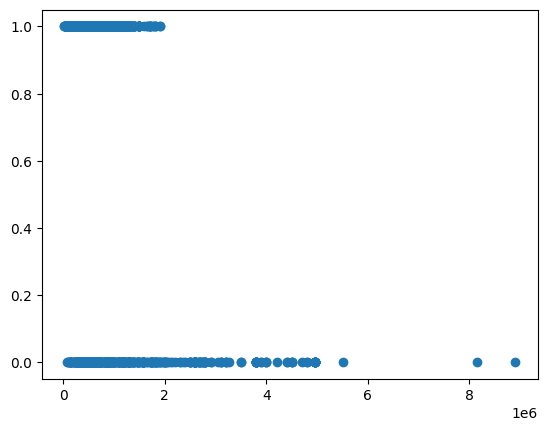

In [139]:
plt.scatter(df['selling_price'], df['transmission_Manual'])

In [140]:
from sklearn.model_selection import train_test_split

In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [142]:
from sklearn.tree import DecisionTreeRegressor

In [143]:
model = DecisionTreeRegressor()

In [144]:
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [145]:
prediction = model.predict(X_test)

In [148]:
from sklearn.metrics import mean_absolute_error

In [149]:
mae = mean_absolute_error(y_test, prediction)

In [150]:
mae

198120.1627363733

In [151]:
df['selling_price'].mean()

np.float64(504127.3117511521)

<Axes: ylabel='selling_price'>

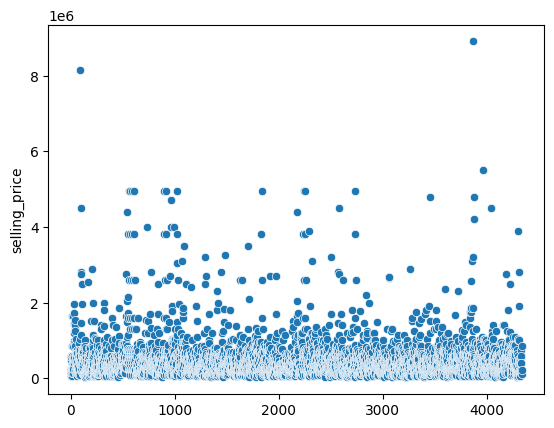

In [152]:
sns.scatterplot(df['selling_price'])

<Axes: >

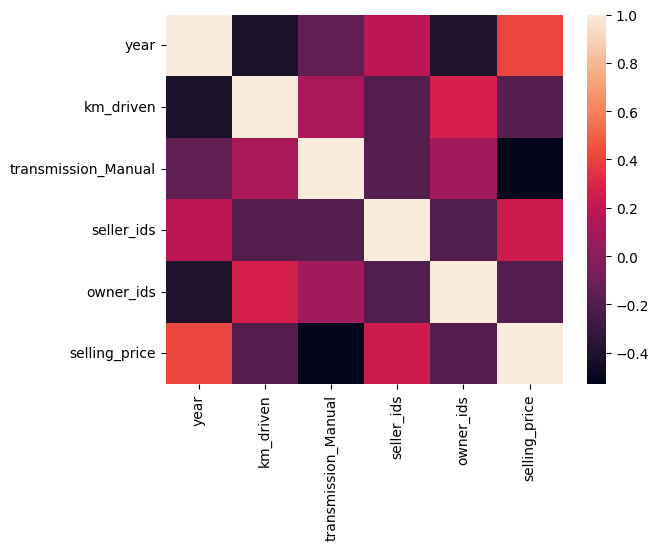

In [154]:
sns.heatmap(corr_data.corr())